In [ ]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import llowfsc
from scoob_llowfsc import psds

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'

/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


952
0


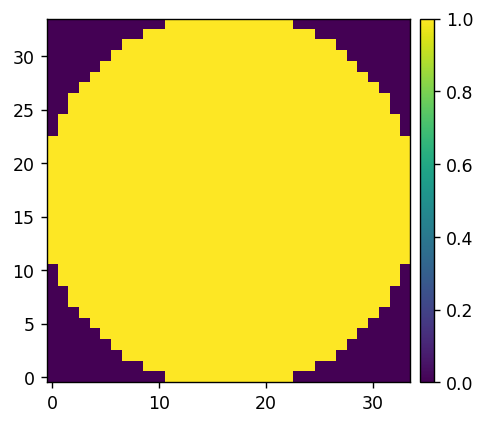

In [ ]:
dm_wfe_name = 'dm00disp01'

dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')

dm_wfe_stream = ImageStream(dm_wfe_name)
# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
wfe_data_path = data_path/f'exp-{today}'/'wfe'
telem_data_path = data_path/f'exp-{date}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{date}'/'unpacked-telem'

In [ ]:
telem.make_dir(exp_path)
telem.make_dir(wfe_data_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

29.0888208681574 nm
0.0005


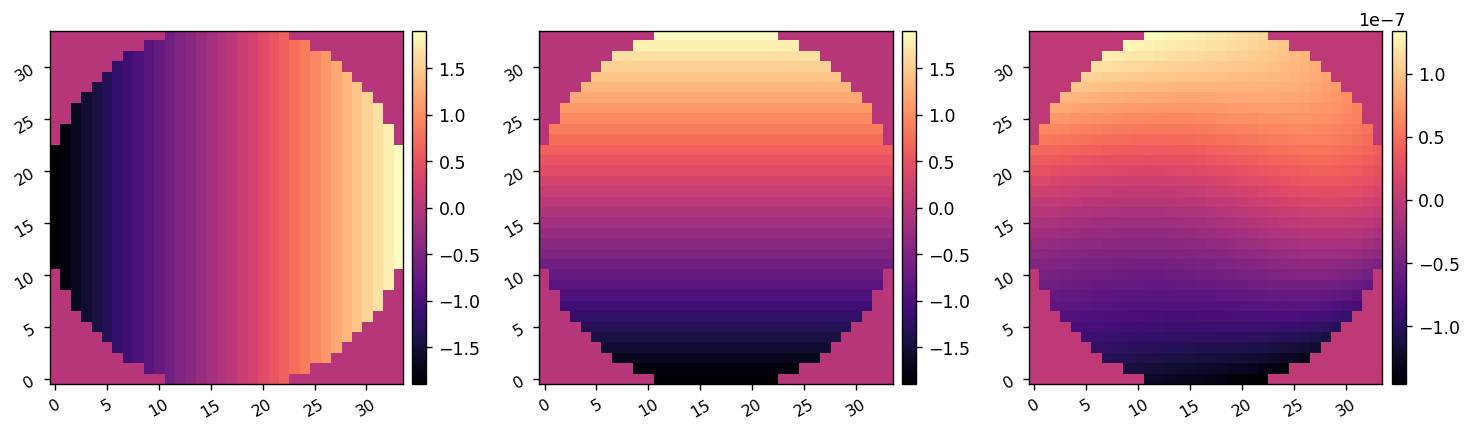

In [ ]:
reload(psds)

total_pupil_diam = 2.4*u.m
dm_beam_diam = 9.1*u.mm
jitter = 10*u.mas 

fmax = 1000*u.Hz
tmax = 10*u.min
tmax = 3*u.hour
# tmax = 5*u.hour

mag = (total_pupil_diam / dm_beam_diam).decompose().value
tt_pv_to_rms = 1/4
tt_at_pupil_pv = np.tan(mag*jitter).value * dm_beam_diam
tt_at_pupil_rms = tt_at_pupil_pv * tt_pv_to_rms
print(tt_at_pupil_rms.to(u.nm))

wfe_modes_rms = np.array(2*[tt_at_pupil_rms.to_value(u.m)] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[20e-9] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[30e-9] + 3*[5e-9] + 5*[2.5e-9])
knee_freqs = np.array([0.1]*2 + [0.001]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(dm_mask, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = psds.generate_freqs(Nf=2**22+1, f_max=fmax)

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = psds.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = psds.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)

wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)]

times = times[times<tmax.to_value(u.s)]
interval = float(times[1] - times[0])
print(interval)

Nsamps = times.shape[0]
tip = wfe_time_series[0]
tilt = wfe_time_series[1]
defocus = wfe_time_series[2]

lo_wfe = xp.sum( wfe_time_series[:, 500, None, None] * wfe_modes, axis=0)
utils.imshow([wfe_modes[0], wfe_modes[1], lo_wfe])


In [ ]:
wfe_data = {
    'times':times,
    'wfe_rms_time_series':wfe_time_series,
    'wfe_modes':wfe_modes,
    'modal_rms':wfe_modes_rms,
    'modal_knee_freqs':knee_freqs,
    'seeds':seeds,
    'fmax':fmax,
}
utils.save_pickle(wfe_data_path/'wfe_data.pkl', wfe_data)

/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/psds.py:149: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(psd_xlims)


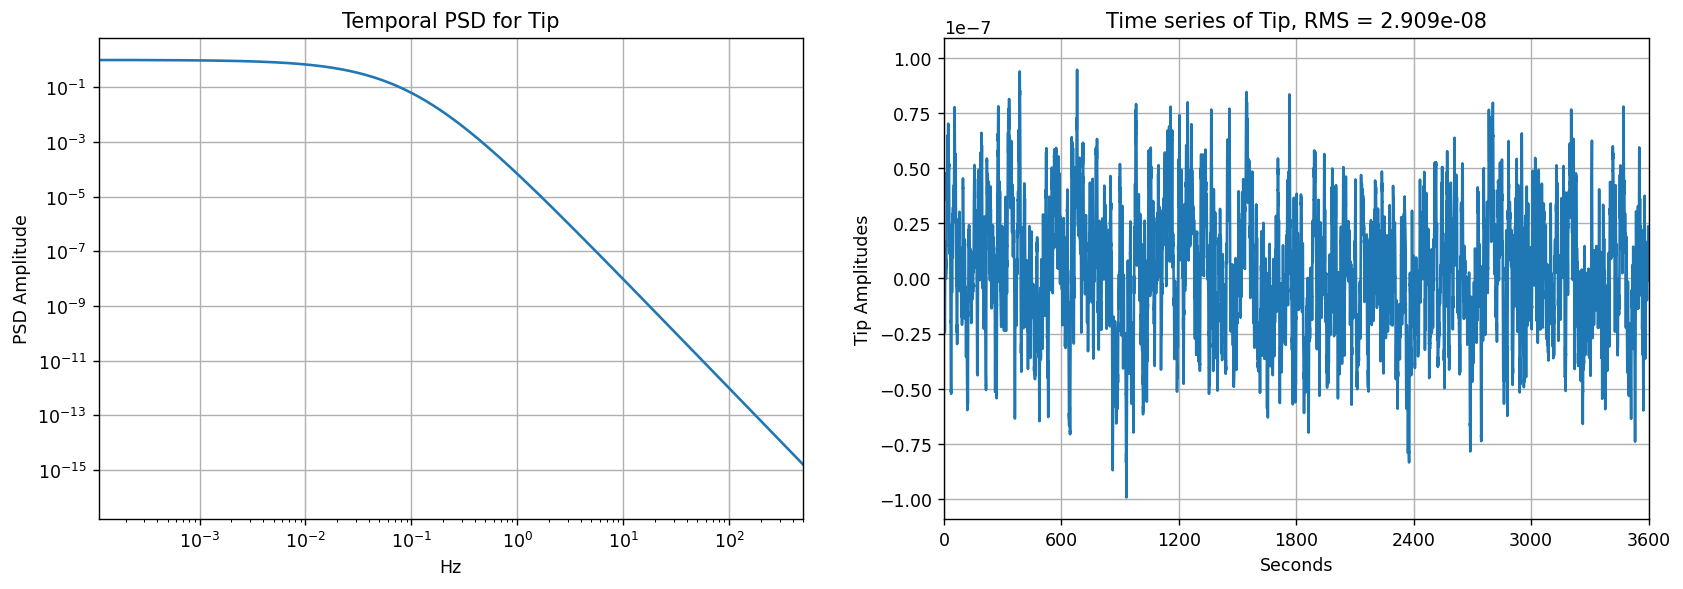

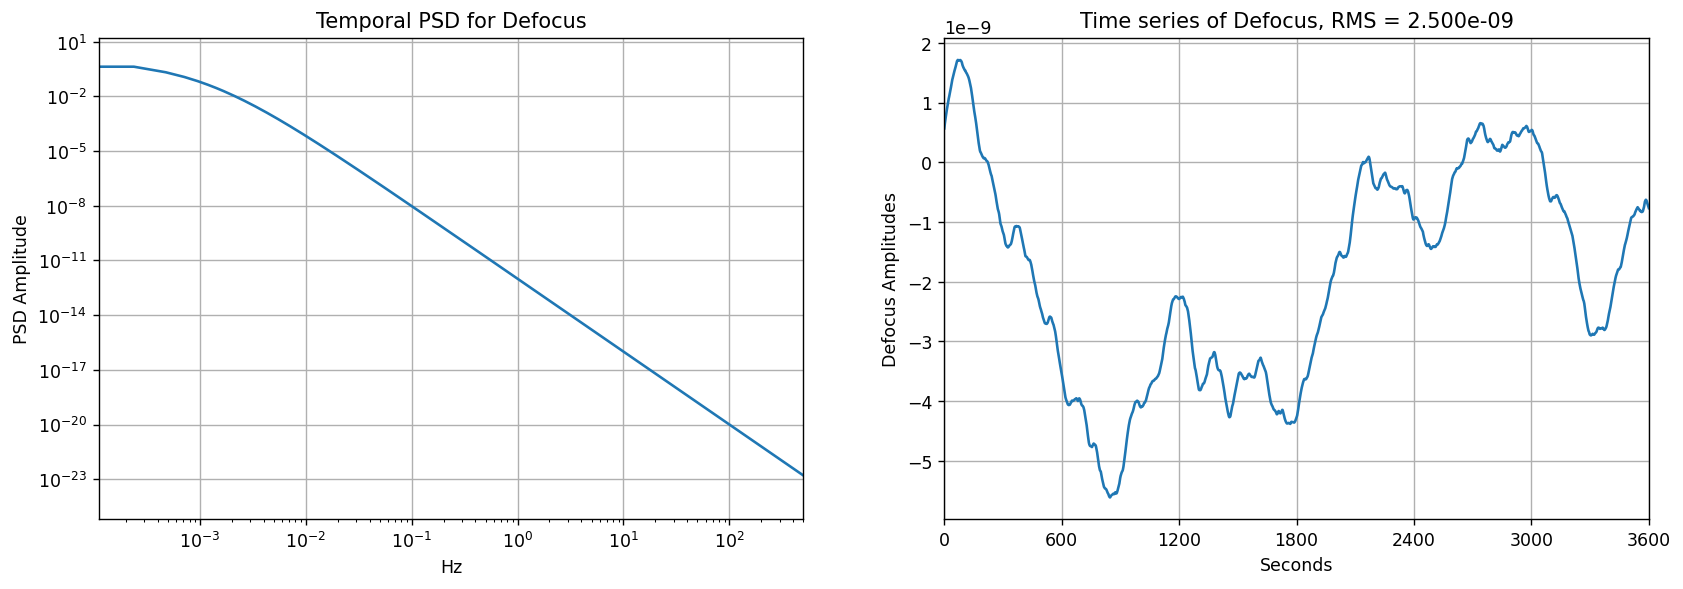

In [4]:
reload(psds)
i = 0
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 500],
    coeff_xlims=[0, 3600],
    coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 2
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 500],
    coeff_xlims=[0, 3600],
    coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)


In [8]:
wfe_modes.shape, wfe_time_series.shape

((10, 34, 34), (10, 7200000))

# Delete telemetry data if needed to keep data organized.

In [ ]:
reload(telem)
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

# Inject WFE with a while loop running at a specific frequency.

In [ ]:
reload(llowfsc)

telem.toggle(1, dm_wfe_name, client0)

llowfsc.inject_wfe(
    ensure_np_array(wfe_time_series[:, :]),
    ensure_np_array(wfe_modes),
    dm_wfe_stream,
    interval,
    interval_offset=0.0,
)

telem.toggle(0, dm_wfe_name, client0)

Injecting WFE ...
Stopped injecting WFE.
